# 10 - Pixel-space generative prior (score-based DA)

An unconditional diffusion model trained on the LOVECLIM anomaly fields replaces
the Gaussian background of 3DVar. Reconstruction is guided posterior sampling: the
EDM reverse process plus an observation-guidance score
`grad log p(y | x_sigma) = -0.5 (y - H x_hat)^T V^-1 (y - H x_hat)`, with
`V = R + sigma^2 gamma` and `x_hat = D(x_sigma; sigma)` (Manshausen et al. 2025;
Rozet and Louppe 2023; Chung et al. 2023).

Two priors mirror the compressors: the older chronological half for the same-model
PPE lane, all ages for the withholding lane. `gamma` (the likelihood inflation) is
the tuned operating point, selected on the held-out split and reported on the test
split, so results land in `outputs/da/generative/` on the same schema notebook 09
compares.

In [1]:
%load_ext autoreload
%autoreload 2

import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube, VARS
from paleoreco.data.cube import apply_anomaly, compute_zscore_stats
from paleoreco.data.splits import chronological_half_split
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.models.diffusion import CircularUNet, EDMDenoiser, load_denoiser, SIGMA_DATA
from paleoreco.training import trainer_diffusion as td
from paleoreco.assim.generative import GuidedSampler, channel_scales
from paleoreco.assim.sampler_pool import SamplerPool
from paleoreco.assim import experiments_generative as gex
from paleoreco.eval import da

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
CKPT = Path("../outputs/checkpoints/10_generative_prior")
FIG = Path("../outputs/figures/10_generative_prior")
CKPT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## Prior cube, chronological split, and the two normalised anomaly frames

Each frame is the per-cell anomaly over its own ages, rescaled per channel to std
`SIGMA_DATA`, the scale the EDM recipe expects. The states, the climatology and the
scaling scalars all come from those ages, so the PPE prior never sees the younger
truths.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

TRUTH_STRIDE = 10
all_idx = np.arange(len(ages))
prior_idx, truth_idx = chronological_half_split(ages, stride=TRUTH_STRIDE)

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))


def frame(idx):
    """safe_valid mask, per-channel scales, and the SIGMA_DATA-scaled anomaly cube over ``idx``.

    The cube is restricted to ``idx`` after centring, so the states, the climatology
    and the scaling scalars all come from the same ages.
    """
    stats = compute_zscore_stats(cube, idx, valid)
    anom = apply_anomaly(cube, stats)[idx]
    scales = channel_scales(anom, stats["safe_valid"])
    norm = anom * (SIGMA_DATA / scales)[None, :, None, None]
    return stats["safe_valid"], scales, anom.astype(np.float64), norm.astype(np.float32)


safe_a, scales_a, anom_a, norm_a = frame(prior_idx)   # older half -> PPE prior
safe_all, scales_all, anom_all, norm_all = frame(all_idx)  # all ages -> withholding prior
print("cube", cube.shape, "| prior states", norm_a.shape[0], "| all states", norm_all.shape[0],
      "| sites", long_ppe["site"].nunique())
print("channel scales (older/all):", np.round(scales_a, 3), np.round(scales_all, 3))

cube (804, 2, 32, 64) | prior states 402 | all states 804 | sites 187
channel scales (older/all): [1.362 0.972] [1.427 1.461]


## Train the two diffusion priors

Small U-Net, EDM denoising-score-matching with EMA. Data is scarce (hundreds of
autocorrelated states), so the epoch count is selected rather than fixed: each lane
first *searches* on a random 75/25 split, stopping once the held-out score has not
improved for `PATIENCE` epochs, then *refits* on every state up to the best epoch.

The held-out score is the EDM loss on a fixed grid of noise levels with fixed noise,
not the training loss: the training loss draws a random noise level per sample, and
that spread is far larger than the epoch-to-epoch change early stopping has to
resolve. It scores the EMA weights, since those are what the checkpoint saves and
the sampler loads.

The refit keeps the cosine horizon at `EPOCHS`, so it follows the same learning-rate
trajectory the search selected on and the chosen epoch keeps its meaning. Set
`RETRAIN = False` once the checkpoints exist to skip both phases.

In [3]:
RETRAIN = False
EPOCHS, BASE, DEPTH, LR, BATCH = 3000, 64, 2, 2e-4, 64
VAL_FRACTION, PATIENCE, SPLIT_SEED = 0.25, 50, 0
T0 = time.time()


def _net():
    return EDMDenoiser(CircularUNet(base_channels=BASE, depth=DEPTH,
                                    grid_shape=tuple(cube.shape[2:])))


def train_prior(norm, safe, scales, path, lane, step):
    """Select the epoch count on a held-out split, then refit on every state."""
    if path.exists() and not RETRAIN:
        print("exists:", path.name)
        return None

    perm = np.random.default_rng(SPLIT_SEED).permutation(len(norm))
    n_val = int(round(VAL_FRACTION * len(norm)))
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    print(f"[{step}/4] {lane} search | {len(train_idx)} train / {len(val_idx)} val "
          f"| max {EPOCHS} ep, patience {PATIENCE}", flush=True)
    t = time.time()
    search = td.train(_net(), norm[train_idx], safe, val_cube=norm[val_idx],
                      patience=PATIENCE, max_epochs=EPOCHS, batch_size=BATCH,
                      lr=LR, device=DEVICE, seed=0)
    n_star = search["best_epoch"] + 1          # 0-based index -> epoch count
    print(f"[{step}/4] {lane} search | done in {time.time() - t:.0f}s "
          f"| best ep {search['best_epoch']} | stopped at {search['stop_epoch']} "
          f"| early={search['stopped_early']} | refit to {n_star}", flush=True)

    print(f"[{step + 1}/4] {lane} refit | {n_star} ep on {len(norm)} states", flush=True)
    t = time.time()
    td.train(_net(), norm, safe, max_epochs=n_star, lr_schedule_epochs=EPOCHS,
             batch_size=BATCH, lr=LR, device=DEVICE, checkpoint_path=str(path),
             channel_scales=scales, seed=0,
             checkpoint_extra={"selection": {
                 "best_epoch": int(search["best_epoch"]),
                 "stop_epoch": int(search["stop_epoch"]),
                 "refit_epochs": int(n_star),
                 "stopped_early": bool(search["stopped_early"]),
                 "patience": int(PATIENCE), "val_fraction": float(VAL_FRACTION),
                 "split_seed": int(SPLIT_SEED), "max_epochs": int(EPOCHS)}})
    print(f"[{step + 1}/4] {lane} refit | done in {time.time() - t:.0f}s "
          f"| wrote {path.name}", flush=True)

    np.savez(CKPT / f"{path.stem}_search.npz",
             **{k: np.asarray(v) for k, v in search["history"].items()})
    return search


search_a = train_prior(norm_a, safe_a, scales_a, CKPT / "diffusion_chunkA.pt", "chunkA", 1)
search_all = train_prior(norm_all, safe_all, scales_all, CKPT / "diffusion_full.pt", "full", 3)
print(f"total {time.time() - T0:.0f}s")

exists: diffusion_chunkA.pt
exists: diffusion_full.pt
total 0s


### Search curves

Red marks where early stopping halted the search, grey the best epoch the refit used.
On the left all three curves are the same fixed-grid score, so the gap between the
training probe and the held-out curve is the generalisation gap, and the gap between
the EMA and live curves is the lag introduced by weight averaging. The right panel is
the random-sigma quantity actually minimised, which sits on its own scale.

If the probe and held-out curves sit on top of each other and never separate, the
random split has no detection power on states this autocorrelated, and the result is
inconclusive rather than evidence of no overfitting.

In [4]:
from paleoreco.eval.diffusion import plot_loss_curves_diffusion

for lane, search in (("chunkA", search_a), ("full", search_all)):
    if search is None:
        continue
    plot_loss_curves_diffusion(
        search["history"], best_epoch=search["best_epoch"],
        stop_epoch=search["stop_epoch"] - 1, title=f"{lane} prior",
        save_path=str(FIG / f"loss_curves_{lane}.png"))
    plt.show()

## Build the two samplers

One sampler per prior for the diagnostics below. The lanes themselves run on a
`SamplerPool`, built and closed around each lane: a single posterior draw occupies a
fraction of the GPU, so spreading independent draws over `N_WORKERS` processes is
most of the run's wall clock. Every draw carries its own seed, so the pooled result
is the serial one.

Ensemble sizes are asymmetric. Below about 16 members a draw costs what one member
costs, so `K_SELECT` is free; the reported `K` is larger because averaging a finite
ensemble inflates the error by `mean(post_var) / K`, and 3DVar carries no such term.

In [5]:
N_STEPS, N_CORRECT, TAU = 64, 2, 0.3
GAMMA_GRID = gex.GAMMA_GRID
K, K_SELECT = 32, 16
N_WORKERS = 4
SAMPLER_KW = dict(n_samples=K, n_steps=N_STEPS, n_correct=N_CORRECT,
                  corrector_tau=TAU, device=DEVICE)


def load_sampler(path, safe):
    net, scales = load_denoiser(path)
    return GuidedSampler(net, np.asarray(scales), safe, **SAMPLER_KW)


sampler_ppe = load_sampler(CKPT / "diffusion_chunkA.pt", safe_a)
sampler_wh = load_sampler(CKPT / "diffusion_full.pt", safe_all)

## Unconditional sanity: did the prior learn the climate?

Given the small training set, check that generated fields resemble real LOVECLIM
states (per-cell std, leading-PC score spread) and that the model is not
regurgitating training snapshots (nearest-neighbour distance).

median NN distance  generated: 52.036  train: 22.731


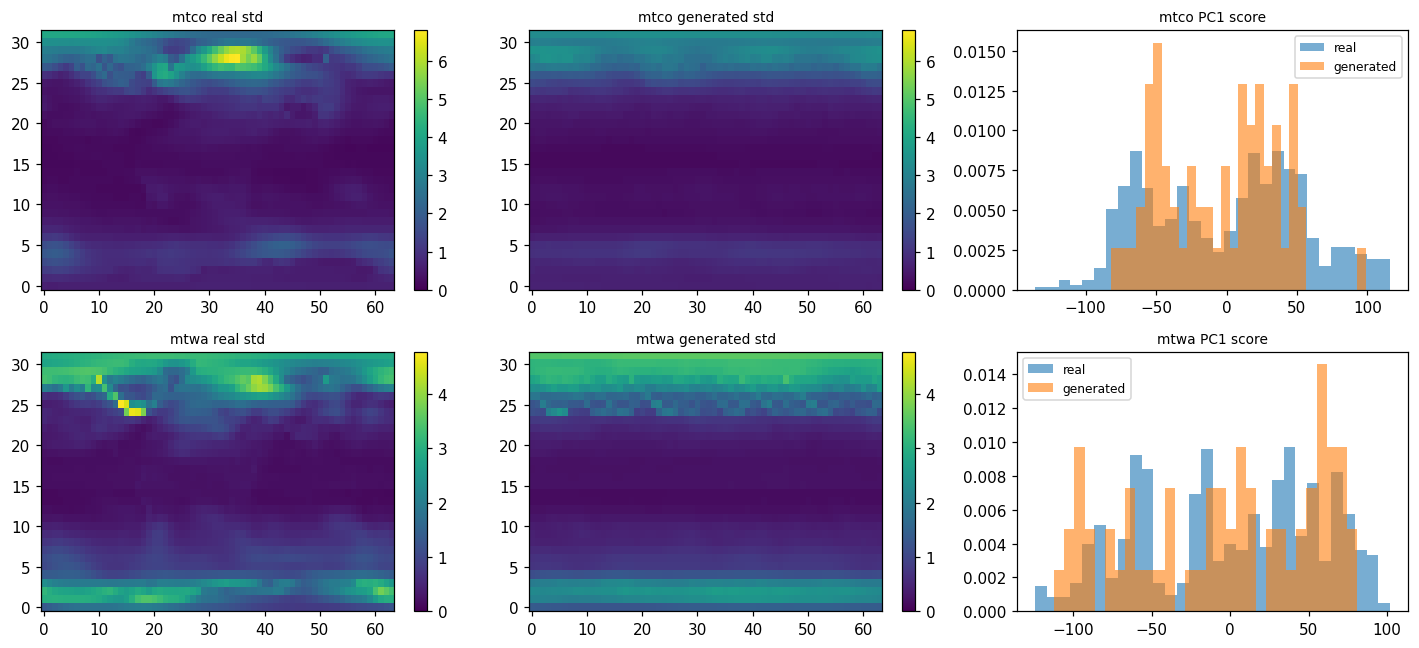

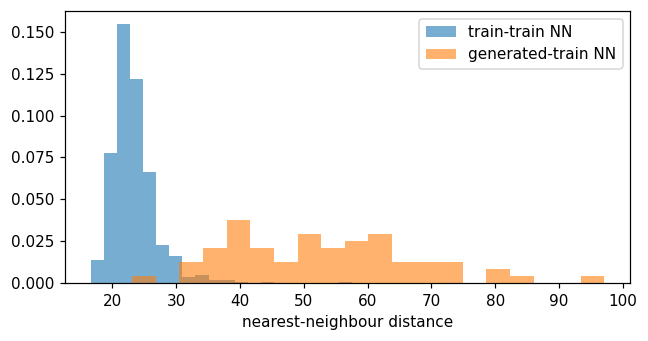

In [6]:
prior_samples = sampler_wh.sample_prior(64, seed=0)   # (64, 2, H, W) anomaly units
gen = prior_samples[:, :, safe_all]
real = anom_all[:, :, safe_all]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for c, name in enumerate(VARS):
    vmax = float(real[:, c].std(0).max())
    for col, (title, field) in enumerate((("real std", real[:, c].std(0)),
                                          ("generated std", gen[:, c].std(0)))):
        m = np.full(safe_all.shape, np.nan); m[safe_all] = field
        ax = axes[c, col]
        im = ax.imshow(m, origin="lower", cmap="viridis", vmin=0, vmax=vmax, aspect="auto")
        ax.set_title(f"{name} {title}", fontsize=9); fig.colorbar(im, ax=ax, fraction=0.046)
    # leading-PC score distribution, generated vs real
    Xr = real[:, c] - real[:, c].mean(0)
    u, s, vt = np.linalg.svd(Xr, full_matrices=False)
    pc = vt[0]
    axes[c, 2].hist((Xr @ pc), bins=30, density=True, alpha=0.6, label="real")
    axes[c, 2].hist(((gen[:, c] - real[:, c].mean(0)) @ pc), bins=30, density=True,
                    alpha=0.6, label="generated")
    axes[c, 2].set_title(f"{name} PC1 score", fontsize=9); axes[c, 2].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "unconditional_quality.png", bbox_inches="tight")

# memorisation: nearest training state for each generated sample vs a train-train baseline.
# cdist avoids the O(N^2 * D) broadcast that would materialise ~20 GB for ~800 states.
from scipy.spatial.distance import cdist

gv = gen.reshape(len(gen), -1)
rv = real.reshape(len(real), -1)
d_gen = cdist(gv, rv).min(1)
dd = cdist(rv, rv); np.fill_diagonal(dd, np.inf)
d_train = dd.min(1)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(d_train, bins=20, density=True, alpha=0.6, label="train-train NN")
ax.hist(d_gen, bins=20, density=True, alpha=0.6, label="generated-train NN")
ax.set_xlabel("nearest-neighbour distance"); ax.legend(); fig.tight_layout()
fig.savefig(FIG / "memorisation.png", bbox_inches="tight")
print("median NN distance  generated:", round(float(np.median(d_gen)), 3),
      " train:", round(float(np.median(d_train)), 3))

## Run the generative lanes

PPE on the older-half prior, withholding on the all-ages prior. `gamma` is swept on
the selection split and reported at its winner on the test split; withholding is
age-subsampled for cost (the stride is recorded in the config). Results share the
`outputs/da/generative/` schema, so notebook 09 compares them against 3DVar.

Each lane opens its own pool and closes it before the next, so only one set of
workers holds GPU memory at a time. `progress_every` counts posterior draws, and the
ETA covers a whole pass, so the four printed blocks are selection and test for each
lane.

In [7]:
d = OUT / "generative"
if d.exists():
    shutil.rmtree(d)

t_lanes = time.time()
with SamplerPool(str(CKPT / "diffusion_chunkA.pt"), safe_a,
                 n_workers=N_WORKERS, **SAMPLER_KW) as pool:
    gex.run_ppe_generative(
        cube, ages, lats, lons, valid, long_ppe, str(d), sampler=pool,
        gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
        truth_stride=TRUTH_STRIDE, progress_every=25)

with SamplerPool(str(CKPT / "diffusion_full.pt"), safe_all,
                 n_workers=N_WORKERS, **SAMPLER_KW) as pool:
    gex.run_withholding_generative(
        cube, ages, lats, lons, valid, long_wh, str(d), sampler=pool,
        gamma_grid=GAMMA_GRID, n_samples=K, n_samples_select=K_SELECT,
        fold_kind="random", age_stride=6, progress_every=100)
print(f"both lanes in {time.time() - t_lanes:.0f}s")
print("wrote", sorted(p.name for p in d.iterdir()))

  ppe selection draws 25/240 (10%, elapsed 42s, eta 365s)
  ppe selection draws 50/240 (21%, elapsed 75s, eta 286s)
  ppe selection draws 75/240 (31%, elapsed 108s, eta 238s)
  ppe selection draws 100/240 (42%, elapsed 142s, eta 199s)
  ppe selection draws 125/240 (52%, elapsed 180s, eta 166s)
  ppe selection draws 150/240 (62%, elapsed 213s, eta 128s)
  ppe selection draws 175/240 (73%, elapsed 246s, eta 91s)
  ppe selection draws 200/240 (83%, elapsed 280s, eta 56s)
  ppe selection draws 225/240 (94%, elapsed 318s, eta 21s)
  ppe test draws 25/41 (61%, elapsed 84s, eta 54s)
  withholding selection draws (withholding_random) 100/3180 (3%, elapsed 143s, eta 4398s)
  withholding selection draws (withholding_random) 200/3180 (6%, elapsed 281s, eta 4183s)
  withholding selection draws (withholding_random) 300/3180 (9%, elapsed 419s, eta 4020s)
  withholding selection draws (withholding_random) 400/3180 (13%, elapsed 557s, eta 3869s)
  withholding selection draws (withholding_random) 500/3

## Prior vs posterior

The gamma tuning curve, the prior-to-posterior variance reduction (reused from the
3DVar diagnostic), and the pointwise prior/posterior distribution at a cell near a
site and one far from any site.

The tuning curve plots `rrmse_ens`, the surface `gamma` was actually selected on:
plain RRMSE carries the finite-ensemble term `mean(post_var) / K`, which grows with
`gamma` and so tilts the curve toward the small end.

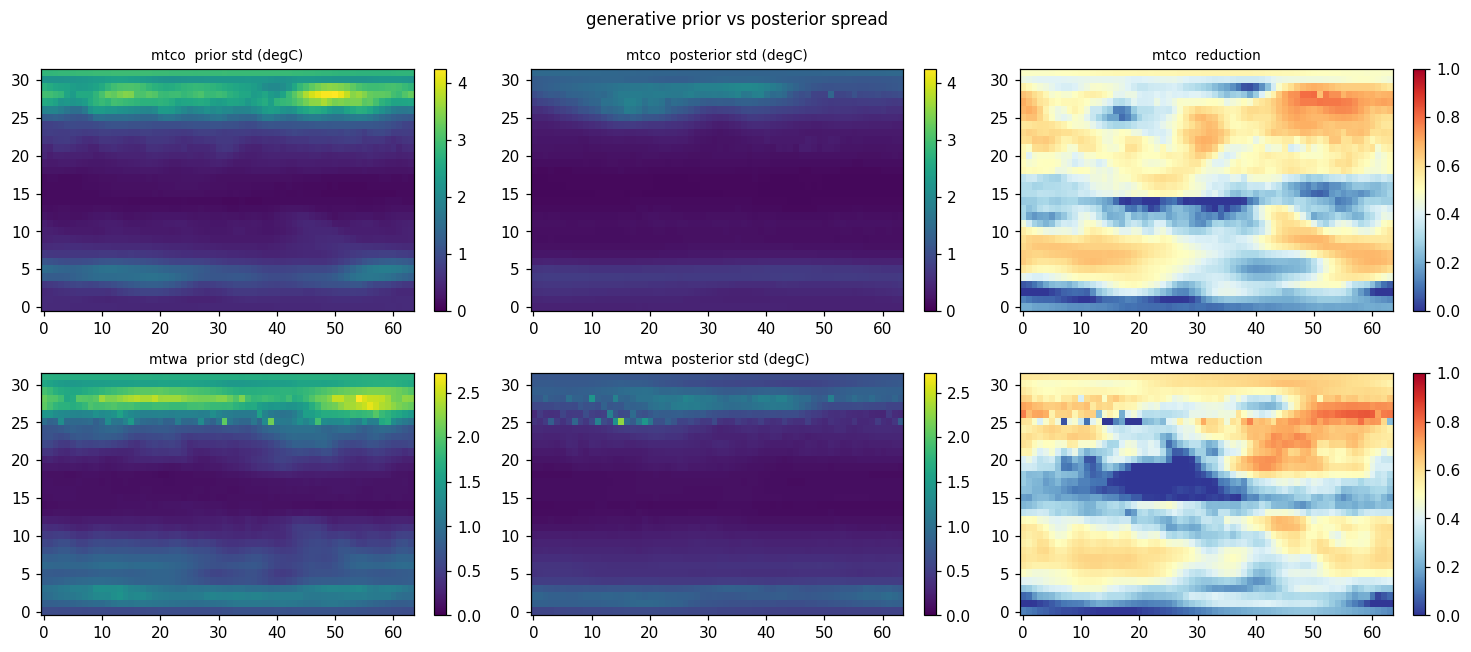

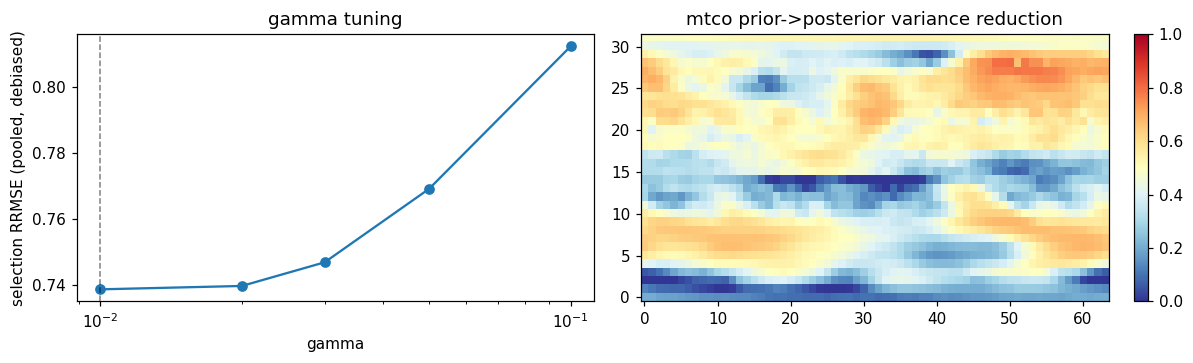

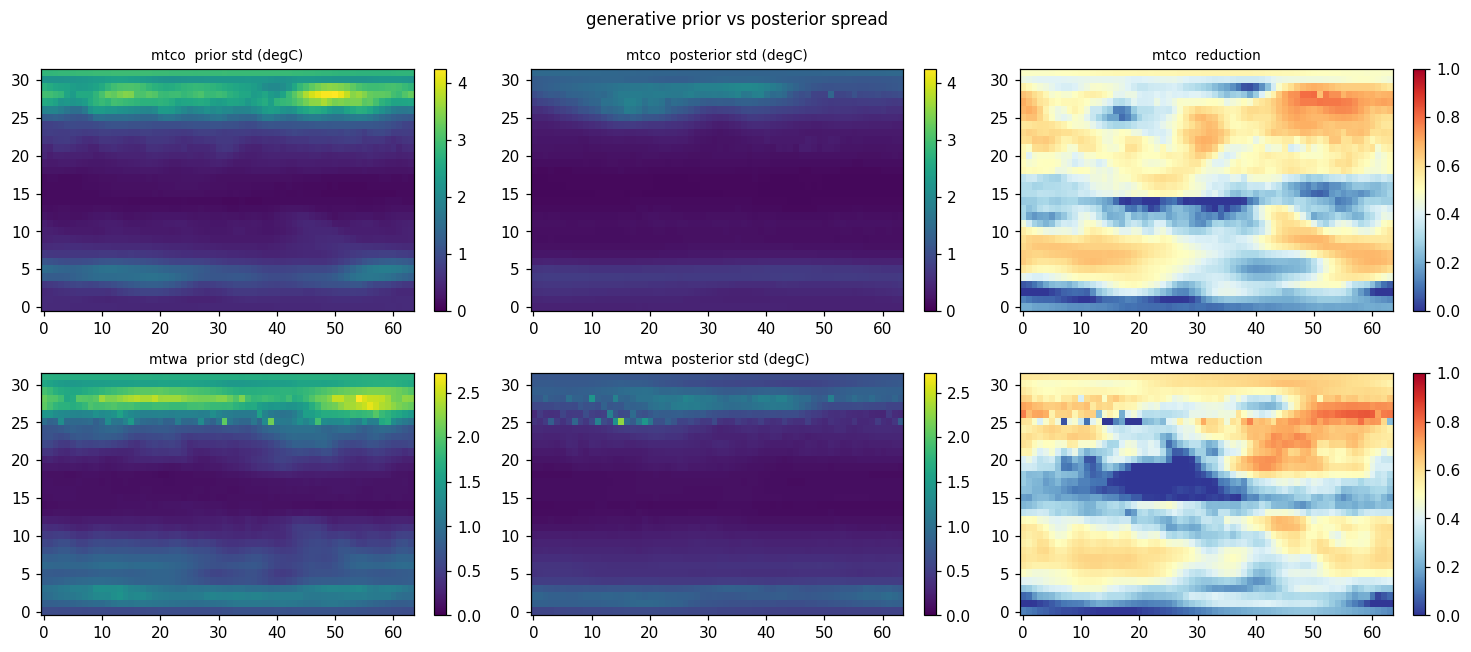

In [8]:
M = pd.read_csv(OUT / "generative" / "metrics.csv")
sel = M[(M.lane == "ppe") & (M.split == "selection") & (M.channel == "pooled")
        & (M.do_event == "all") & (M.metric == "rrmse_ens")].sort_values("b_scale")

z = np.load(OUT / "generative" / "ppe_analysis.npz")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(sel["b_scale"], sel["value"], "o-"); ax[0].set_xscale("log")
ax[0].axvline(float(z["b_scales"][0]), color="k", lw=1, ls="--", alpha=0.5)
ax[0].set_xlabel("gamma"); ax[0].set_ylabel("selection RRMSE (pooled, debiased)")
ax[0].set_title("gamma tuning")

red = da.uncertainty_reduction(z["prior_ens_var"], z["post_var"][0].mean(axis=0))
im = ax[1].imshow(np.where(safe_all, red[0], np.nan), origin="lower", cmap="RdYlBu_r",
                  vmin=0, vmax=1, aspect="auto")
ax[1].set_title("mtco prior->posterior variance reduction")
fig.colorbar(im, ax=ax[1], fraction=0.046)
fig.tight_layout(); fig.savefig(FIG / "gamma_and_variance_reduction.png", bbox_inches="tight")

da.plot_prior_posterior_uncertainty(
    z["prior_ens_var"], z["post_var"][0].mean(axis=0), safe_all, VARS,
    title="generative prior vs posterior spread",
    save_path=str(FIG / "uncertainty_reduction_generative.png"))

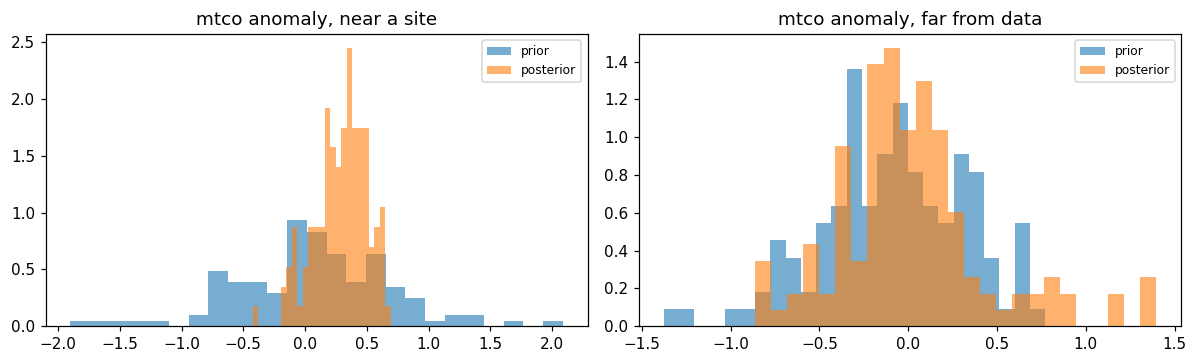

In [9]:
# Pointwise prior vs posterior at a near-site and a far cell (mtco), for one truth.
from paleoreco.assim.observations import observations_at_age
from paleoreco.assim.experiments import _obs_geometry

n_cells = len(lats) * len(lons)
safe_flat = np.broadcast_to(safe_a, (len(VARS), *safe_a.shape)).ravel()
age0 = int(z["drawn_ages"][0, -1])
geom = _obs_geometry(observations_at_age(long_ppe, age0), lats, lons, safe_flat)
truth0 = z["truth_anom"][0]
y0 = truth0.ravel()[geom["gather"]]
gamma_star = float(z["b_scales"][0])
post = sampler_ppe.sample_posterior(geom["gather"], y0, geom["sse"], gamma_star, 128, seed=1)
prior = sampler_ppe.sample_prior(128, seed=2)

# Index the mtco channel (cells 0..n_cells-1) at an observed site and at the void.
near = int(geom["gather"][0]) % n_cells
far = int(np.argmax(da.nearest_obs_distance(lats, lons, geom["lat"], geom["lon"])))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, (cell, label) in zip(ax, ((near, "near a site"), (far, "far from data"))):
    a.hist(prior.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6, label="prior")
    a.hist(post.reshape(128, -1)[:, cell], bins=25, density=True, alpha=0.6, label="posterior")
    a.set_title(f"mtco anomaly, {label}"); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "pointwise_prior_posterior.png", bbox_inches="tight")

## Reading

The cross-method comparison against 3DVar (skill, calibration, prior-to-posterior,
gallery) lives in `09_da_comparison`, which discovers `outputs/da/generative/`
automatically. Bimodality-recovery near D-O transitions is the next milestone.